# DISEASE → POVERTY: Visualisation

Detailed visualisation of the DISEASE→POVERTY conceptual metaphor mapping
from the LCC corpus: kernel heatmaps, sparse network graphs, and permutation null distributions.

In [1]:
# Configuration
# Set the source and target concept labels here.
# Labels must match CMSourceAnnotation sourceConcept / targetConcept values
# in the LCC corpus (case-sensitive, e.g. 'DISEASE', 'POVERTY').

SOURCE_CONCEPT = "STRUGGLE"
TARGET_CONCEPT = "POVERTY"

EDGE_FRACTION = 0.20  # keep top X fraction of edges (e.g. 0.20 = top 20%)
N_PERMS  = 1000   # permutation test iterations


In [2]:
from pathlib import Path
import numpy as np
from intrarepresentational_alignment.data import load_lcc
from intrarepresentational_alignment.embedding import Embedder
from intrarepresentational_alignment.models import EmbeddingModel
from intrarepresentational_alignment.graph import TopFraction
from intrarepresentational_alignment.analysis import group_domain_pairs, analyse_domain_pairs

LCC_PATH  = Path("data/en_small.xml")
instances = load_lcc(LCC_PATH)
all_pairs = group_domain_pairs(instances)

KEY = (SOURCE_CONCEPT, TARGET_CONCEPT)
if KEY not in all_pairs:
    available = sorted(all_pairs, key=lambda k: len(all_pairs[k]), reverse=True)
    raise ValueError(
        f'No pairs found for {SOURCE_CONCEPT!r} -> {TARGET_CONCEPT!r}.\n'
        f'Top available pairs: {available[:10]}'
    )

pairs     = all_pairs[KEY]
src_texts = [s for s, _ in pairs]
tgt_texts = [t for _, t in pairs]
print(f'{SOURCE_CONCEPT} -> {TARGET_CONCEPT}: {len(pairs)} expression pairs')

embedder = Embedder(EmbeddingModel.ALL_MINILM_L6_V2)
result   = analyse_domain_pairs(
    {KEY: pairs}, embedder, n_permutations=N_PERMS,
    rng=np.random.default_rng(42),
    return_kernels=True,
)[KEY]

K_S_dense  = result.K_source
K_T_dense  = result.K_target
K_S_sparse = TopFraction(EDGE_FRACTION)(K_S_dense)
K_T_sparse = TopFraction(EDGE_FRACTION)(K_T_dense)
cka_res    = result.cka
ged_res    = result.ged

print(f'CKA = {cka_res.observed:.3f}  (p = {cka_res.p_value:.3f})')
print(f'GED = {ged_res.observed:.3f}  (p = {ged_res.p_value:.3f})')

c:\Users\Student\Documents\Repositories\intrarepresentational-alignment\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


STRUGGLE -> POVERTY: 18 expression pairs
CKA = 0.262  (p = 0.916)
GED = 0.354  (p = 0.993)


## Kernel matrices: before and after pruning

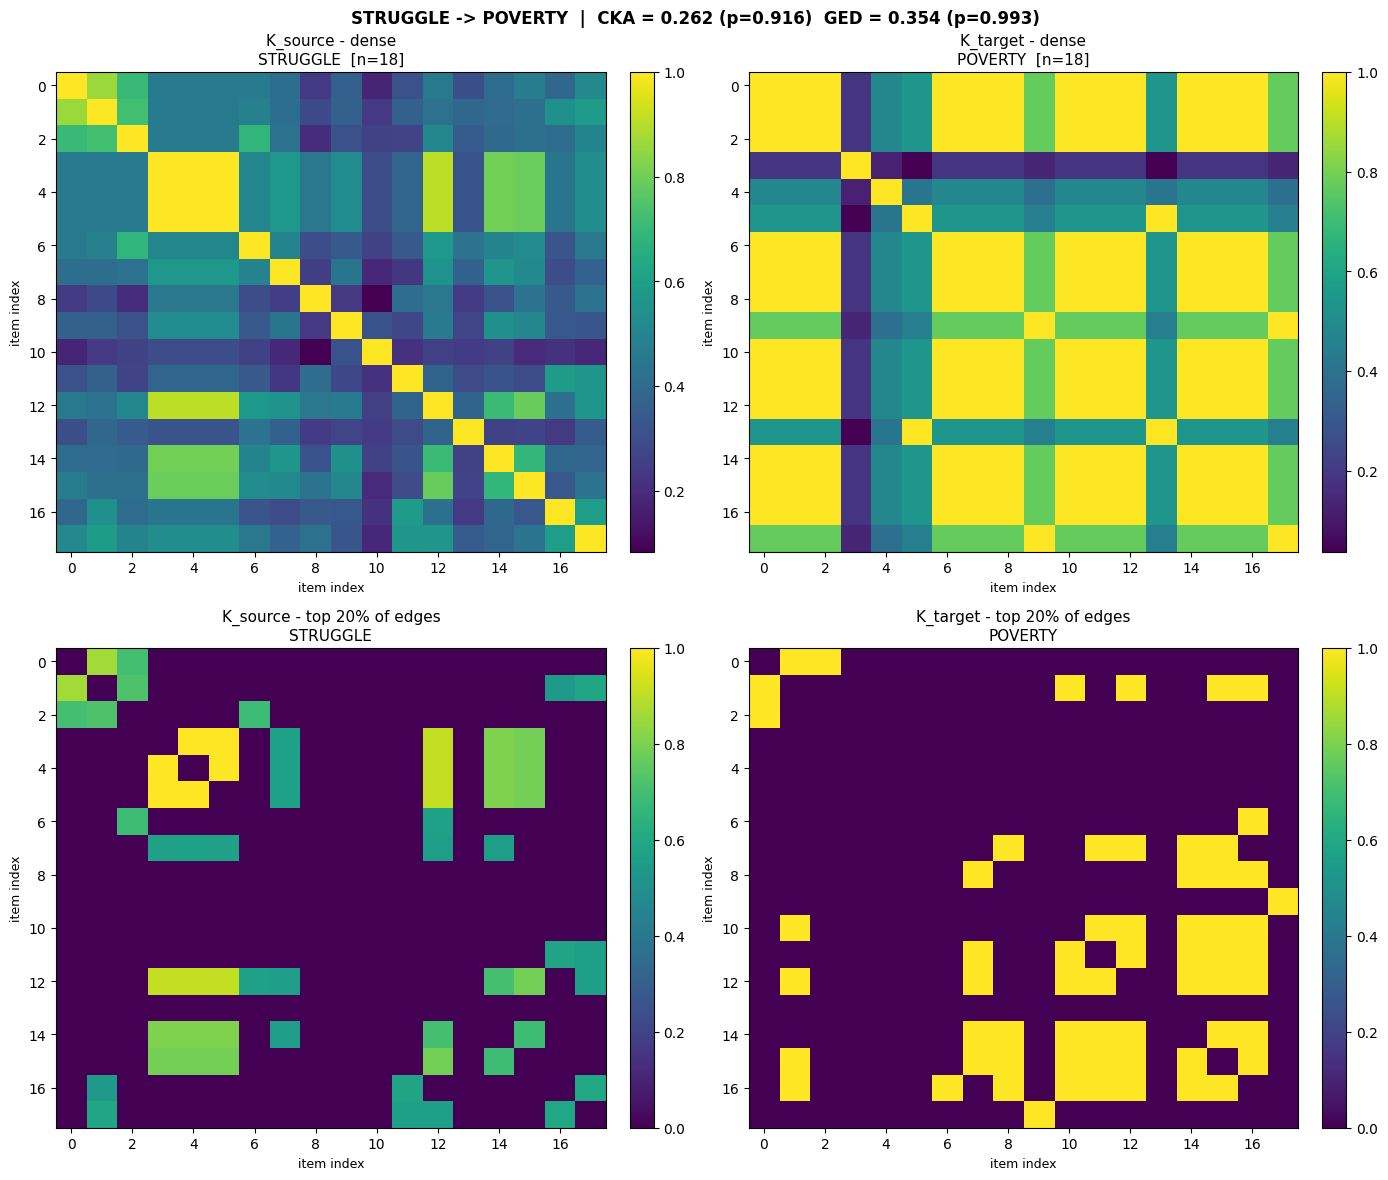

In [3]:
from intrarepresentational_alignment.viz import plot_kernel_heatmaps
plot_kernel_heatmaps(K_S_dense, K_T_dense, K_S_sparse, K_T_sparse,
                     SOURCE_CONCEPT, TARGET_CONCEPT, EDGE_FRACTION, cka_res, ged_res)

## Network graphs (TopFraction sparsification)

Nodes are individual expressions; edges are retained by TopFraction and weighted by cosine similarity.

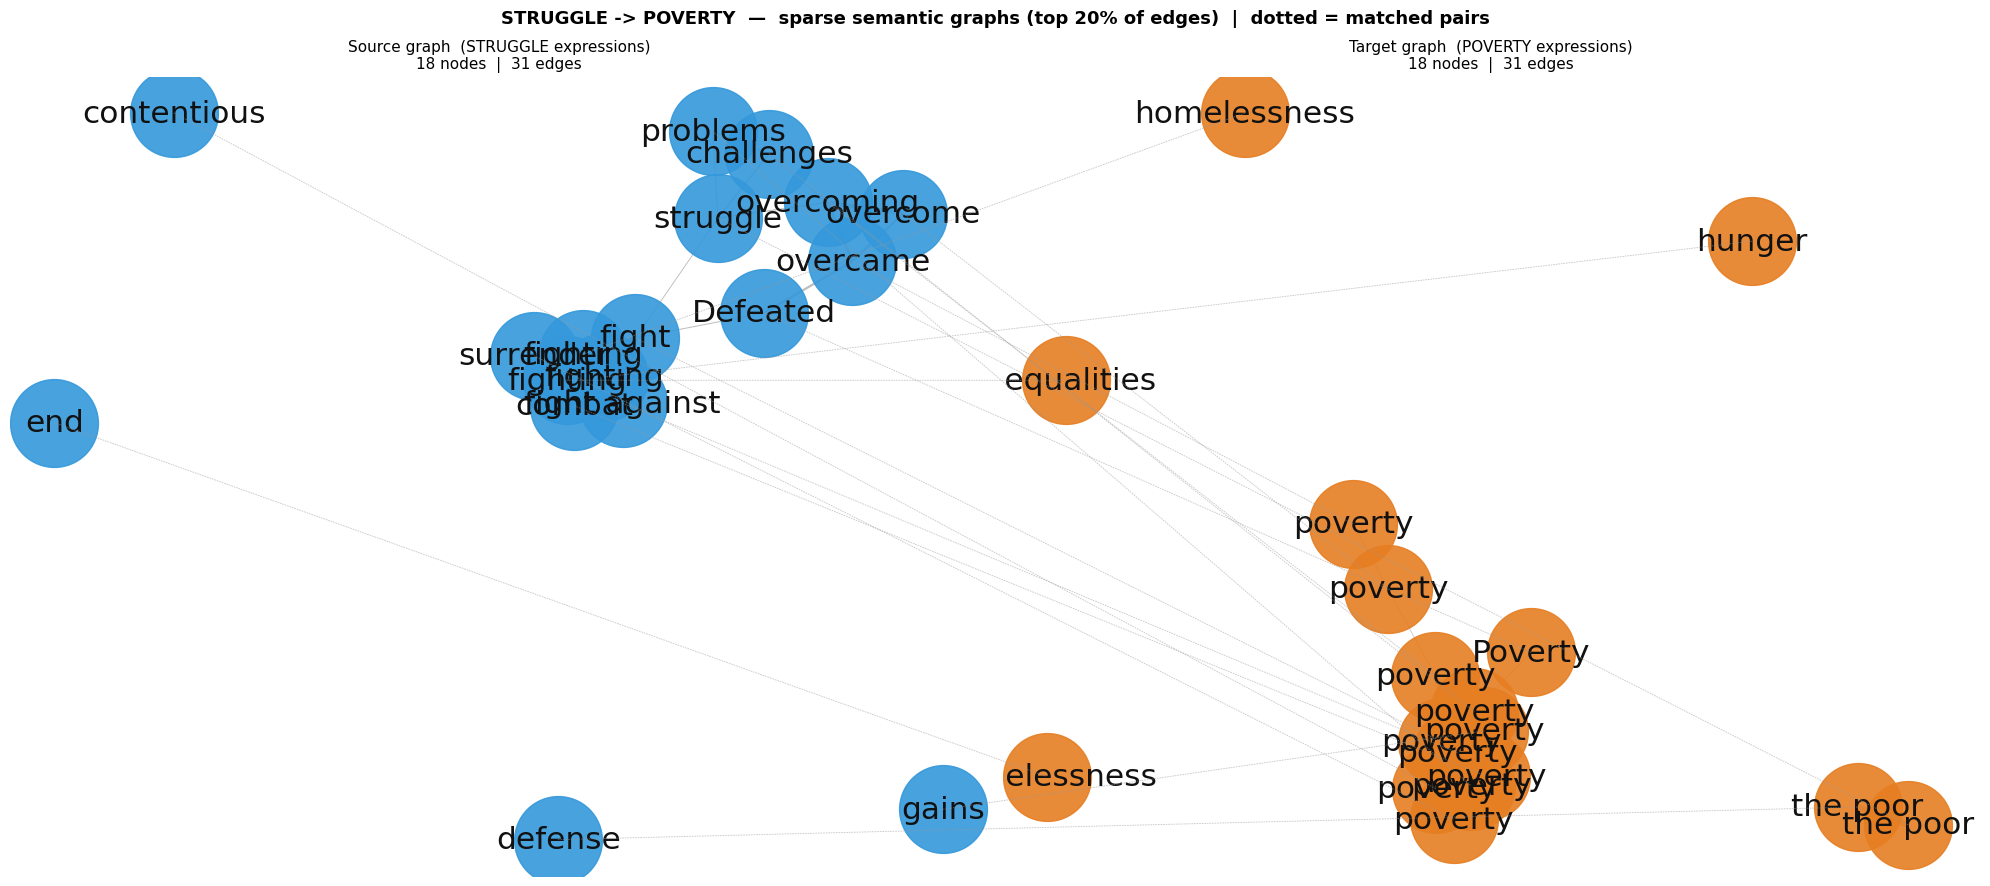

In [4]:
from intrarepresentational_alignment.viz import plot_semantic_graphs
plot_semantic_graphs(K_S_sparse, K_T_sparse, src_texts, tgt_texts,
                     SOURCE_CONCEPT, TARGET_CONCEPT, EDGE_FRACTION)

## Permutation null distributions

Grey histograms = CKA/GED scores under the null (pairs shuffled). Red line = observed score.

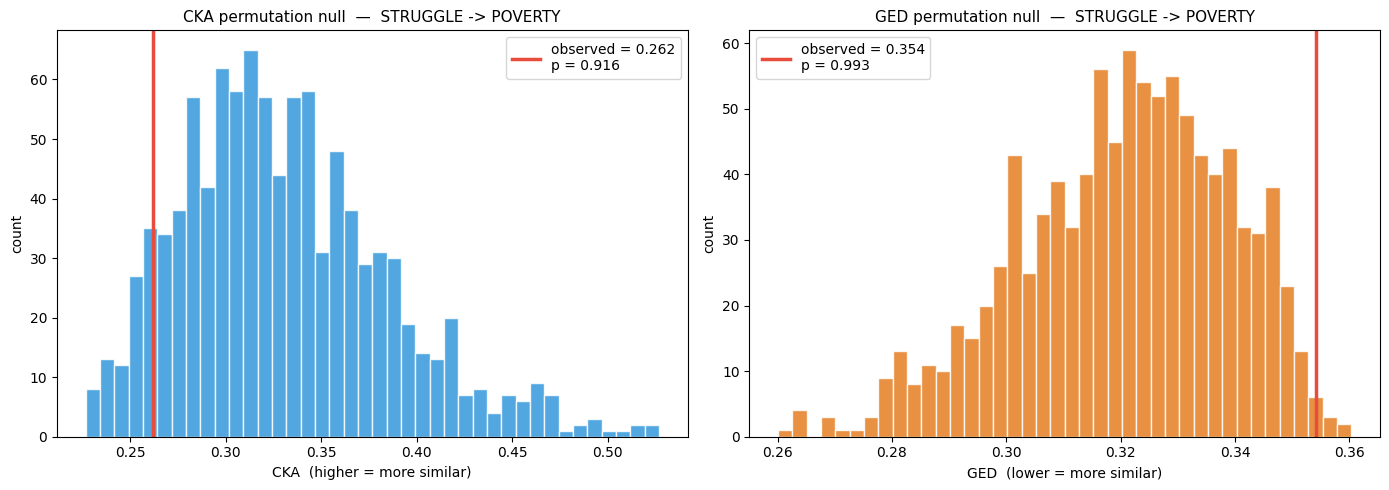

In [5]:
from intrarepresentational_alignment.viz import plot_null_distributions
plot_null_distributions(cka_res, ged_res, SOURCE_CONCEPT, TARGET_CONCEPT)